In [1]:
# Week 2 - Task 1 : Advanced Data Cleaning
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
df = pd.read_csv('retail_store_sales.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (12575, 11)

Columns: ['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit', 'Quantity', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date', 'Discount Applied']


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [2]:
# Missing values check 
print("Missing Values:")
print(df.isnull().sum())
print("\nMissing % per column:")
print((df.isnull().sum() / len(df) * 100).round(2))


Missing Values:
Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

Missing % per column:
Transaction ID       0.00
Customer ID          0.00
Category             0.00
Item                 9.65
Price Per Unit       4.84
Quantity             4.80
Total Spent          4.80
Payment Method       0.00
Location             0.00
Transaction Date     0.00
Discount Applied    33.39
dtype: float64


In [3]:
df['Item'] = df['Item'].fillna('Unknowm')
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Price Per Unit'].median())
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())
df['Total Spent'] = df['Total Spent'].fillna(df['Total Spent'].median())
df['Discount Applied'] = df['Discount Applied'].fillna(df['Discount Applied'].mode()[0])
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64


C:\Users\sarth\AppData\Local\Temp\ipykernel_27408\3484446875.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Discount Applied'] = df['Discount Applied'].fillna(df['Discount Applied'].mode()[0])


In [4]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)
df.columns = ['transaction_id', 'customer_id', 'category', 'item', 
              'price_per_unit', 'quantity', 'total_spent', 
              'payment_method', 'location', 'transaction_date', 
              'discount_applied']

print("\nNew column names:")
print(df.columns.tolist())

Duplicate rows: 0
After removing duplicates: (12575, 11)

New column names:
['transaction_id', 'customer_id', 'category', 'item', 'price_per_unit', 'quantity', 'total_spent', 'payment_method', 'location', 'transaction_date', 'discount_applied']


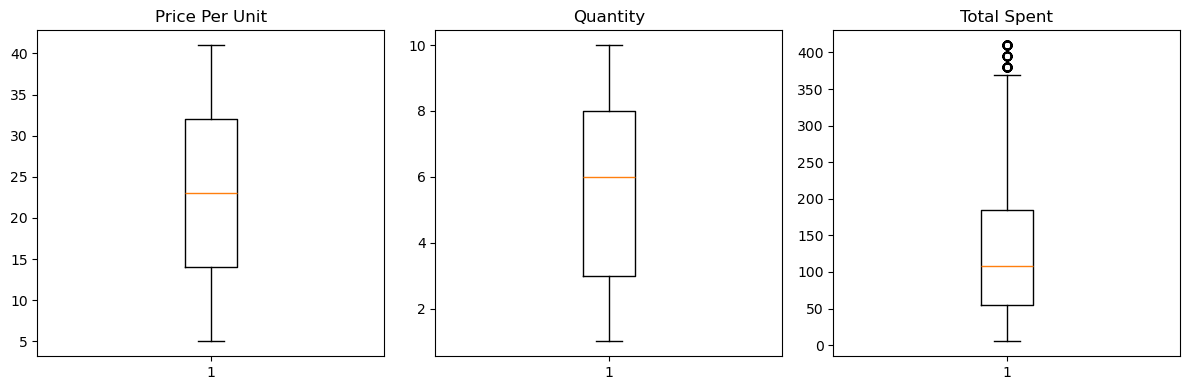

In [5]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.boxplot(df['price_per_unit'])
plt.title('Price Per Unit')

plt.subplot(1, 3, 2)
plt.boxplot(df['quantity'])
plt.title('Quantity')

plt.subplot(1, 3, 3)
plt.boxplot(df['total_spent'])
plt.title('Total Spent')

plt.tight_layout()
plt.savefig('boxplot_outliers.png')
plt.show()

In [6]:
Q1 = df['total_spent'].quantile(0.25)
Q3 = df['total_spent'].quantile(0.75)
IQR = Q3 - Q1 

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['total_spent'] >= lower) & (df['total_spent'] <= upper)]
print("After outlier removal:", df.shape)

After outlier removal: (12418, 11)


In [7]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['category_encoded'] = le.fit_transform(df['category'])
df['payment_method_encoded'] = le.fit_transform(df['payment_method'])
df['location_encoded'] = le.fit_transform(df['location'])

df['discount_applied'] = df['discount_applied'].map({True: 1, False: 0, 'True': 1, 'False': 0})

print("Encoding done!")
print(df[['category', 'category_encoded', 'payment_method', 'payment_method_encoded']].head())

Encoding done!
        category  category_encoded  payment_method  payment_method_encoded
0     Patisserie                 7  Digital Wallet                       2
1  Milk Products                 6  Digital Wallet                       2
2       Butchers                 1     Credit Card                       1
3      Beverages                 0     Credit Card                       1
4           Food                 4  Digital Wallet                       2


In [8]:
df.to_csv('retail_store_cleaned.csv', index=False)
print("Cleaned dataset saved!")
print("Final shape:",df.shape)

Cleaned dataset saved!
Final shape: (12418, 14)


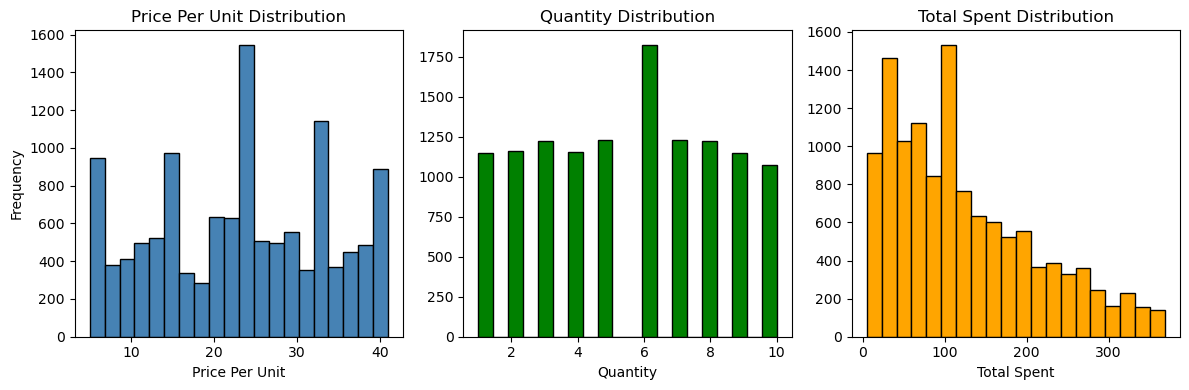

In [9]:
# Task 2: EDA 
# Histogram - Price Per Unit Distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(df['price_per_unit'], bins=20, color='steelblue', edgecolor='black')
plt.title('Price Per Unit Distribution')
plt.xlabel('Price Per Unit')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(df['quantity'], bins=20, color='green', edgecolor='black')
plt.title('Quantity Distribution')
plt.xlabel('Quantity')

plt.subplot(1, 3, 3)
plt.hist(df['total_spent'], bins=20, color='orange', edgecolor='black')
plt.title('Total Spent Distribution')
plt.xlabel('Total Spent')

plt.tight_layout()
plt.savefig('histograms.png')
plt.show()

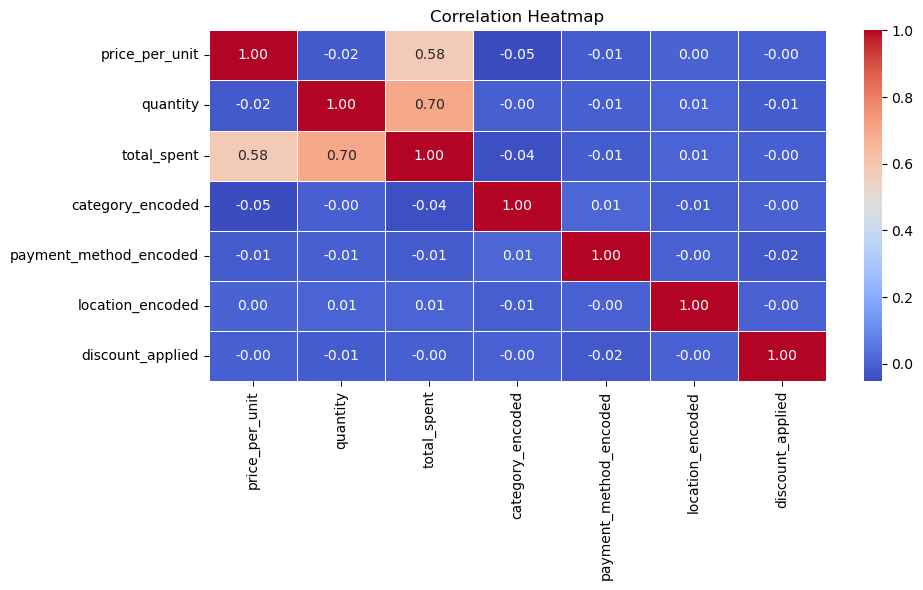

In [10]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
numeric_cols = df[['price_per_unit', 'quantity', 'total_spent', 'category_encoded', 'payment_method_encoded', 'location_encoded', 'discount_applied']]
correlation = numeric_cols.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()


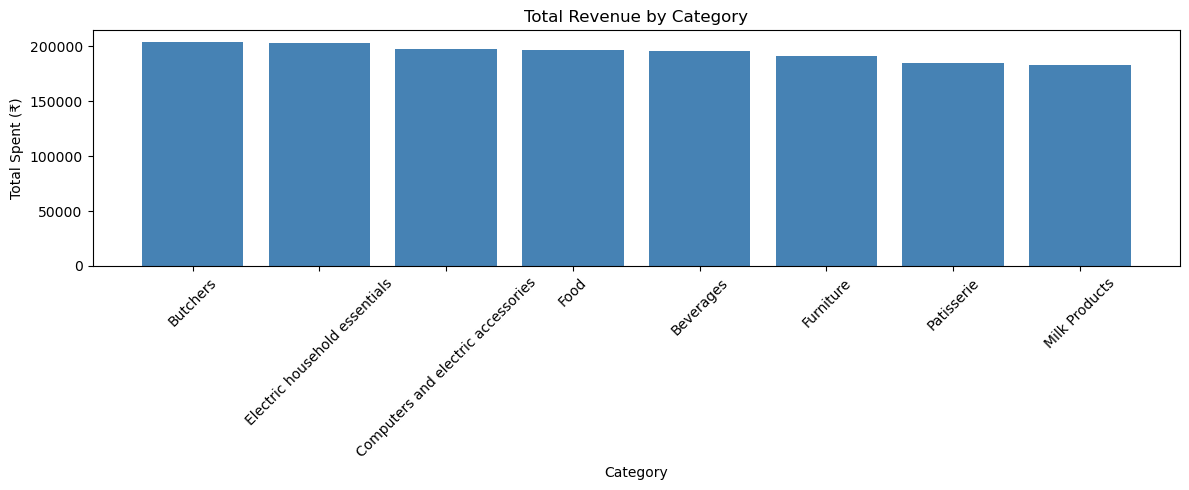

In [11]:
# Bar Chart - Revenue by Category
plt.figure(figsize=(12, 5))
category_sales = df.groupby('category')['total_spent'].sum().sort_values(ascending=False)
plt.bar(category_sales.index, category_sales.values, color='steelblue')
plt.title('Total Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Total Spent (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('bar_category_revenue.png')
plt.show()


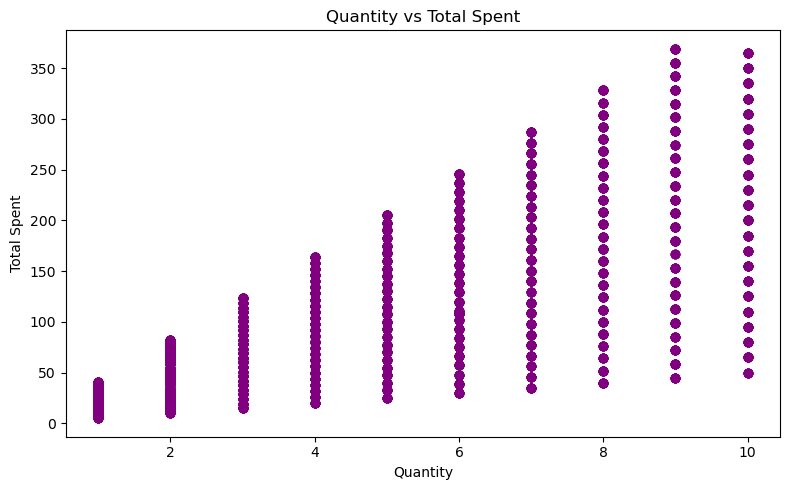

In [12]:
# Scatter Plot 
plt.figure(figsize=(8, 5))
plt.scatter(df['quantity'], df['total_spent'], alpha=0.3, color='purple')
plt.title('Quantity vs Total Spent')
plt.xlabel('Quantity')
plt.ylabel('Total Spent')
plt.tight_layout()
plt.savefig('sactter_quantity_spent.png')
plt.show()

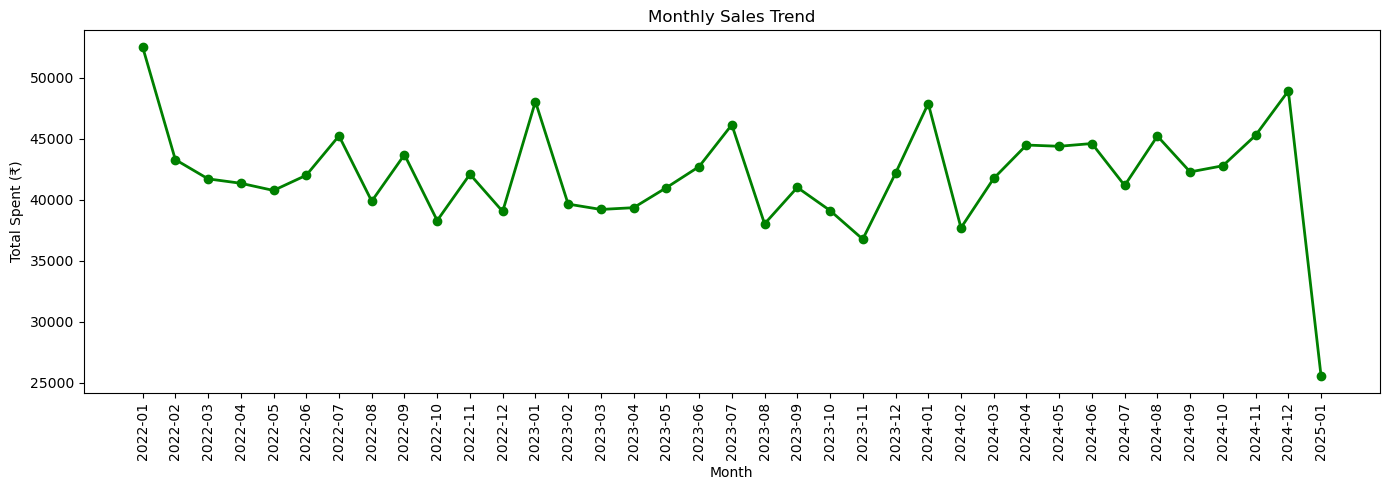

In [13]:
# Line Chart - Monthly Sales Trend
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['month_year'] = df['transaction_date'].dt.to_period('M')

monthly_sales = df.groupby('month_year')['total_spent'].sum()

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o', color='green', linewidth=2)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Spent (₹)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('line_monthly_trend.png')
plt.show()

In [14]:
# Task 2: Key Insights
print("=" * 50)
print("KEY INSIGHTS FROM EDA")
print("=" * 50)

# Insight 1 - Top Category
top_cat = df.groupby('category')['total_spent'].sum().sort_values(ascending=False).index[0]
top_cat_revenue = df.groupby('category')['total_spent'].sum().sort_values(ascending=False).values[0]
print(f"\n1. Top Category: {top_cat} with revenue ₹{top_cat_revenue:,.2f}")

# Insight 2 - Top Payment Method
top_payment = df['payment_method'].value_counts().index[0]
print(f"\n2. Most Used Payment Method: {top_payment}")

# Insight 3 - Average Order Value
avg_order = df['total_spent'].mean()
print(f"\n3. Average Transaction Value: ₹{avg_order:,.2f}")

# Insight 4 - Top Location
top_location = df.groupby('location')['total_spent'].sum().sort_values(ascending=False).index[0]
print(f"\n4. Top Revenue Location: {top_location}")

KEY INSIGHTS FROM EDA

1. Top Category: Butchers with revenue ₹204,140.00

2. Most Used Payment Method: Cash

3. Average Transaction Value: ₹125.27

4. Top Revenue Location: Online


In [15]:
# Task 3: Sales Prediction Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np 

X = df[['price_per_unit', 'quantity', 'category_encoded', 'payment_method_encoded', 'location_encoded', 'discount_applied']]
y = df['total_spent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (9934, 6)
Testing set size: (2484, 6)


In [16]:
# Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results:")
print(f"RMSE: {lr_rmse:.2f}")
print(f"MAE: {lr_mae:.2f}")
print(f"R2 Score: {lr_r2:.4f}")

Linear Regression Results:
RMSE: 35.44
MAE: 25.58
R2 Score: 0.8408


In [17]:
# Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results:")
print(f"RMSE: {rf_rmse:.2f}")
print(f"MAE: {rf_mae:.2f}")
print(f"R2 Score:{rf_r2:.4f}")

Random Forest Results:
RMSE: 23.40
MAE: 7.85
R2 Score:0.9306


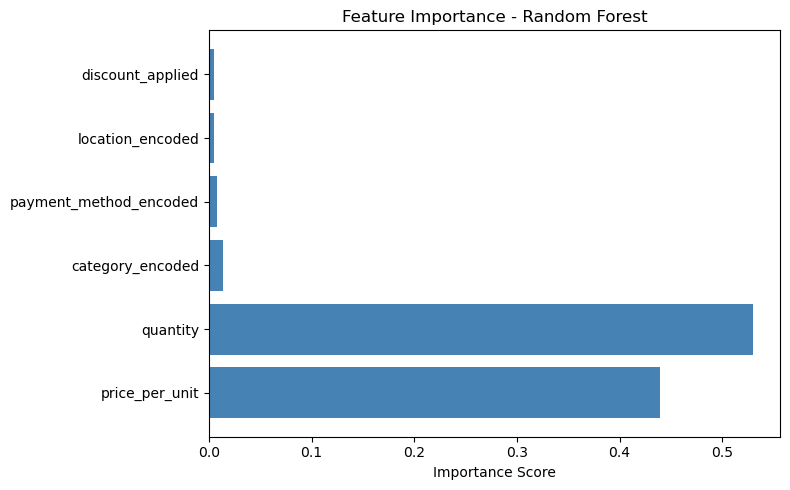

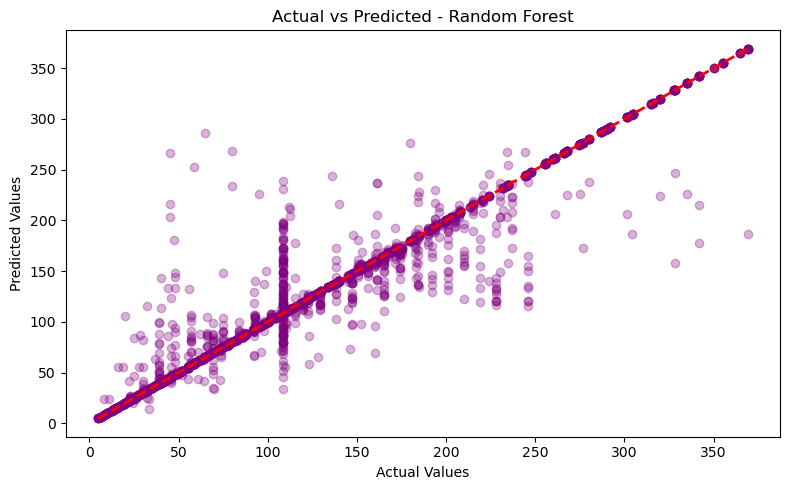

In [18]:
# Feature Importance Chart
plt.figure(figsize=(8, 5))
feature_names = ['price_per_unit', 'quantity', 'category_encoded', 
                 'payment_method_encoded', 'location_encoded', 'discount_applied']
importances = rf_model.feature_importances_
plt.barh(feature_names, importances, color='steelblue')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# Actual vs Predicted Plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, rf_pred, alpha=0.3, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title('Actual vs Predicted - Random Forest')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
plt.show()

In [19]:
# Model Comparison Summary
print("=" * 50)
print("MODEL COMPARISON SUMMARY")
print("=" * 50)
print(f"\nLinear Regression:")
print(f"  RMSE: {lr_rmse:.2f}")
print(f"  MAE:  {lr_mae:.2f}")
print(f"  R2:   {lr_r2:.4f}")

print(f"\nRandom Forest:")
print(f"  RMSE: {rf_rmse:.2f}")
print(f"  MAE:  {rf_mae:.2f}")
print(f"  R2:   {rf_r2:.4f}")

print("\nBest Model: Random Forest")
print("Reason: Higher R2 (0.93) and lower RMSE and MAE")


df.to_csv('retail_store_final.csv', index=False)
print("\nFinal dataset saved!")

MODEL COMPARISON SUMMARY

Linear Regression:
  RMSE: 35.44
  MAE:  25.58
  R2:   0.8408

Random Forest:
  RMSE: 23.40
  MAE:  7.85
  R2:   0.9306

Best Model: Random Forest
Reason: Higher R2 (0.93) and lower RMSE and MAE

Final dataset saved!
